<a href="https://colab.research.google.com/github/illelias/Stock-Analysis/blob/main/CUS_690.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ["ALPHAVANTAGE_API_KEY"] = "ALPHA_VAN"

In [ ]:
import os
import time
import requests
import pandas as pd

API_KEY = os.getenv("ALPHAVANTAGE_API_KEY")
SYMBOL = "AAPL"

def _call_alpha_vantage(params, max_retries=3, sleep_sec=12):
    url = "https://www.alphavantage.co/query"
    for attempt in range(1, max_retries + 1):
        r = requests.get(url, params=params, timeout=30)
        try:
            j = r.json()
        except ValueError:
            raise RuntimeError(f"Non-JSON response: HTTP {r.status_code}, text={r.text[:300]}")

        # Handle common Alpha Vantage meta messages
        if "Note" in j:
            # Rate limit hit
            if attempt == max_retries:
                raise RuntimeError(f"Rate limit: {j['Note']}")
            time.sleep(sleep_sec)
            continue

        if "Information" in j:
            # Often shows for premium-only or quota issues
            raise PermissionError(j["Information"])

        if "Error Message" in j:
            raise ValueError(j["Error Message"])

        return j

    raise RuntimeError("Max retries exceeded without a usable response.")

def fetch_daily_dataframe(symbol, api_key, prefer_adjusted=True, outputsize="compact"):
    if not api_key:
        raise RuntimeError("No API key found in ALPHAVANTAGE_API_KEY.")

    # 1) Try DAILY_ADJUSTED first (free for most plans, but may be gated for you)
    if prefer_adjusted:
        params = {
            "function": "TIME_SERIES_DAILY_ADJUSTED",
            "symbol": symbol,
            "outputsize": outputsize,
            "apikey": api_key
        }
        try:
            j = _call_alpha_vantage(params)
            key = "Time Series (Daily)"
            if key not in j:
                # Some responses nest differently; adjusted uses the same key label for data
                raise KeyError(f"Expected '{key}' in response keys: {list(j.keys())}")
            ts = pd.DataFrame(j[key]).T
            ts.index = pd.to_datetime(ts.index)
            ts = ts.rename(columns={
                "1. open": "Open",
                "2. high": "High",
                "3. low": "Low",
                "4. close": "Close",
                "5. adjusted close": "Adj Close",
                "6. volume": "Volume"
            }).astype(float).sort_index()
            return ts
        except PermissionError as e:
            # Premium-gated → fall back below
            print(f"[INFO] Adjusted daily appears gated: {e}\nFalling back to TIME_SERIES_DAILY...")

    # 2) Fall back to non-adjusted DAILY
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": symbol,
        "outputsize": outputsize,
        "apikey": api_key
    }
    j = _call_alpha_vantage(params)
    key = "Time Series (Daily)"
    if key not in j:
        raise KeyError(f"Expected '{key}' in response keys: {list(j.keys())}")

    ts = pd.DataFrame(j[key]).T
    ts.index = pd.to_datetime(ts.index)
    ts = ts.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume",
        "4. close": "Close"
    }).astype(float).sort_index()

    # Mirror adjusted naming so your SMA code is unchanged
    ts["Adj Close"] = ts["Close"]
    return ts

# --- USE IT ---
df = fetch_daily_dataframe(SYMBOL, API_KEY, prefer_adjusted=True, outputsize="compact")
print(df.tail(3))  # quick sanity check


[INFO] Adjusted daily appears gated: Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints
Falling back to TIME_SERIES_DAILY...
               Open    High     Low   Close      Volume  Adj Close
2025-10-09  257.805  258.00  253.14  254.04  38322012.0     254.04
2025-10-10  254.940  256.38  244.00  245.27  61999098.0     245.27
2025-10-13  249.380  249.69  245.56  247.66  38142942.0     247.66


[INFO] Adjusted daily appears gated: Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints
Falling back to TIME_SERIES_DAILY...


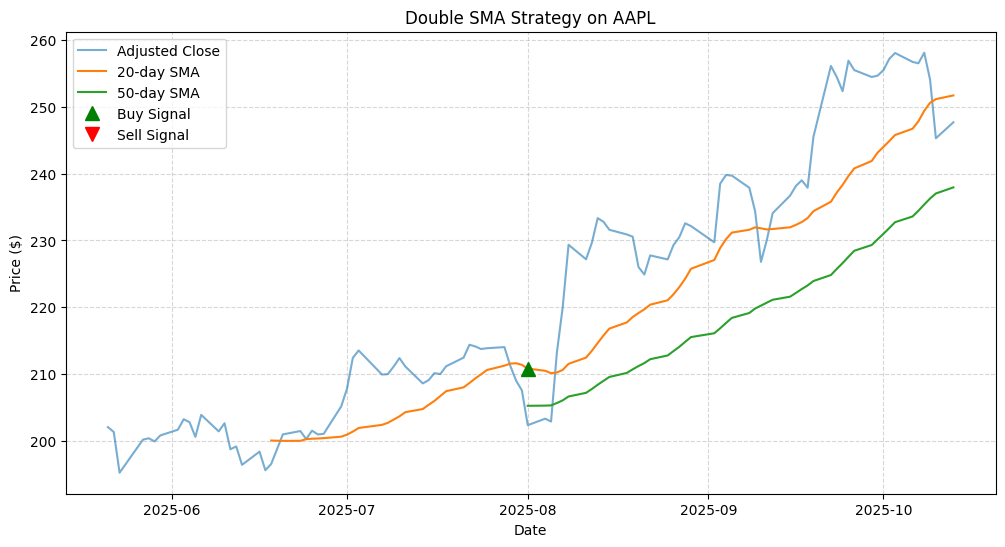

In [ ]:
import matplotlib.pyplot as plt

# --- CONFIG ---
SYMBOL = "AAPL"
SHORT_WINDOW = 20
LONG_WINDOW = 50

# --- FETCH DATA ---
df = fetch_daily_dataframe(SYMBOL, API_KEY, prefer_adjusted=True, outputsize="compact")

# --- CALCULATE MOVING AVERAGES ---
df["SMA_Short"] = df["Adj Close"].rolling(SHORT_WINDOW).mean()
df["SMA_Long"]  = df["Adj Close"].rolling(LONG_WINDOW).mean()

# --- GENERATE BUY/SELL SIGNALS ---
df["Signal"] = 0
df.iloc[SHORT_WINDOW:, df.columns.get_loc("Signal")] = (df["SMA_Short"][SHORT_WINDOW:] > df["SMA_Long"][SHORT_WINDOW:]).astype(int)
df["Position"] = df["Signal"].diff()

# --- PLOT ---
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Adj Close"], label="Adjusted Close", alpha=0.6)
plt.plot(df.index, df["SMA_Short"], label=f"{SHORT_WINDOW}-day SMA", linewidth=1.5)
plt.plot(df.index, df["SMA_Long"], label=f"{LONG_WINDOW}-day SMA", linewidth=1.5)

# Plot buy signals (green ^)
plt.plot(df[df["Position"] == 1].index,
         df["SMA_Short"][df["Position"] == 1],
         "^", markersize=10, color="g", label="Buy Signal")

# Plot sell signals (red v)
plt.plot(df[df["Position"] == -1].index,
         df["SMA_Short"][df["Position"] == -1],
         "v", markersize=10, color="r", label="Sell Signal")

plt.title(f"Double SMA Strategy on {SYMBOL}")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

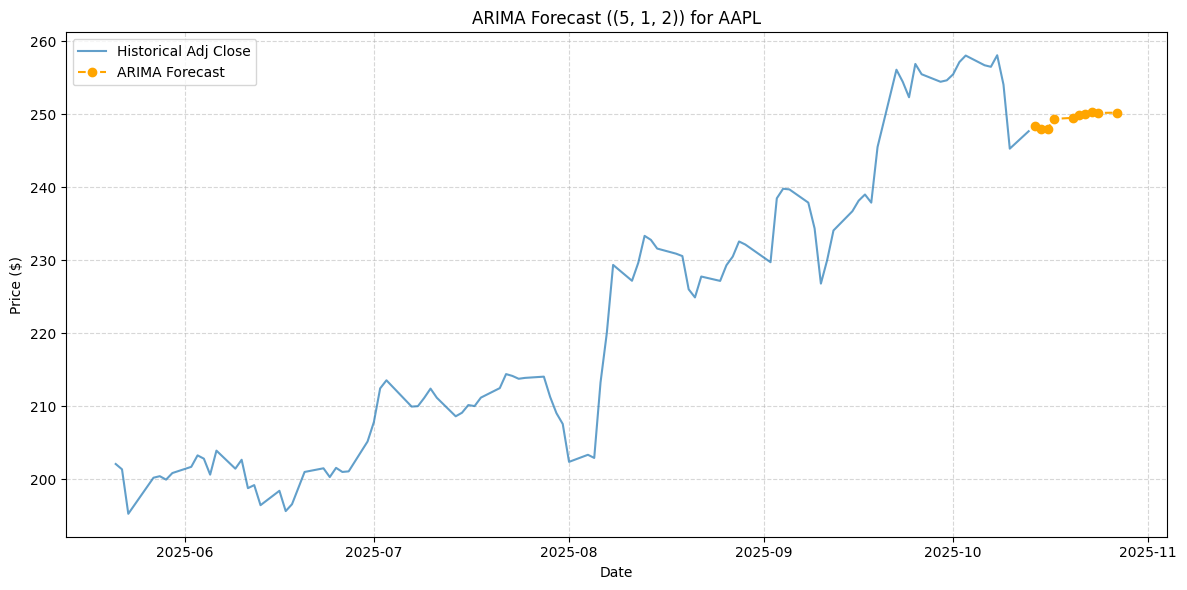

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

warnings.simplefilter('ignore', ConvergenceWarning)

# --- ARIMA Forecasting ---

# Use only the 'Adj Close' column
ts = df["Adj Close"].dropna()

# Define ARIMA model order (p,d,q) — you can experiment with these values
order = (5, 1, 2)

# Fit the model
model = ARIMA(ts, order=order)
model_fit = model.fit()

# Forecast future values
forecast_steps = 10  # days into the future
forecast = model_fit.forecast(steps=forecast_steps)

# Generate forecast dates
last_date = ts.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')  # 'B' = business day

# Create a DataFrame for plotting
forecast_df = pd.DataFrame({'Forecast': forecast.values}, index=forecast_index)

# --- PLOT FORECAST ---
plt.figure(figsize=(12,6))
plt.plot(ts.index, ts, label="Historical Adj Close", alpha=0.7)
plt.plot(forecast_df.index, forecast_df["Forecast"], label="ARIMA Forecast", color='orange', linestyle='--', marker='o')

plt.title(f"ARIMA Forecast ({order}) for {SYMBOL}")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

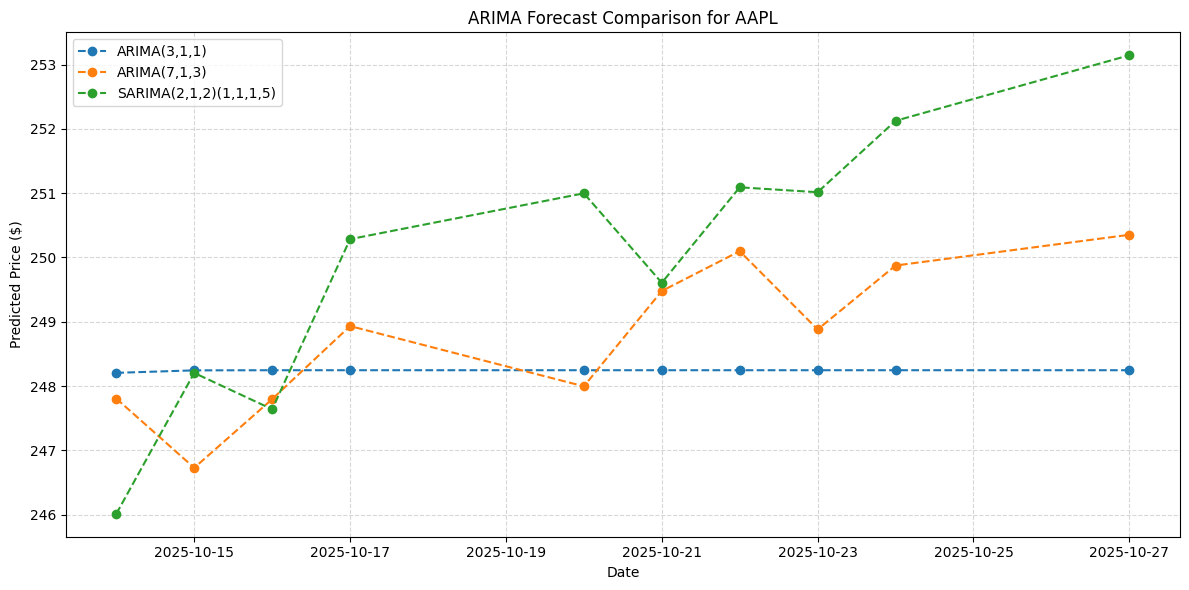

Model AIC Comparison:
ARIMA(3, 1, 1): 524.73
ARIMA(7, 1, 3): 530.42
SARIMA(2,1,2)(1,1,1,5): 512.56


In [ ]:
# --- ARIMA Forecasting Comparison (Without Historical Adjustment) ---

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

try:
    from pmdarima import auto_arima
    has_autoarima = True
except ImportError:
    has_autoarima = False

warnings.simplefilter('ignore', ConvergenceWarning)

ts = df["Adj Close"].dropna()

#Simple ARIMA(3,1,1) ---
order1 = (3, 1, 1)
model1 = ARIMA(ts, order=order1)
fit1 = model1.fit()
forecast1 = fit1.forecast(steps=10)

#Higher-order ARIMA(7,1,3) ---
order2 = (7, 1, 3)
model2 = ARIMA(ts, order=order2)
fit2 = model2.fit()
forecast2 = fit2.forecast(steps=10)

#Seasonal ARIMA (SARIMA)
seasonal_order = (1, 1, 1, 5)  # weekly seasonality (business week)
sarima_model = SARIMAX(ts, order=(2,1,2), seasonal_order=seasonal_order)
sarima_fit = sarima_model.fit()
forecast3 = sarima_fit.forecast(steps=10)

# Forecast Indez by Time
last_date = ts.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1),
                               periods=10, freq='B')  # 'B' = business days

# Before displaying the 3 forecasts
forecast_df = pd.DataFrame({
    'ARIMA(3,1,1)': forecast1.values,
    'ARIMA(7,1,3)': forecast2.values,
    'SARIMA(2,1,2)(1,1,1,5)': forecast3.values
}, index=forecast_index)


# Ploting the 3 Forecasts
plt.figure(figsize=(12, 6))
for col in forecast_df.columns:
    plt.plot(forecast_df.index, forecast_df[col], linestyle='--', marker='o', label=col)

plt.title(f"ARIMA Forecast Comparison for {SYMBOL}")
plt.xlabel("Date")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# AIC (Akaike Information Criterion) Per Model
print("Model AIC Comparison:")
print(f"ARIMA{order1}: {fit1.aic:.2f}")
print(f"ARIMA{order2}: {fit2.aic:.2f}")
print(f"SARIMA(2,1,2)(1,1,1,5): {sarima_fit.aic:.2f}")
if has_autoarima:
    print(f"AutoARIMA (best found): {auto_model.aic():.2f}")


In [ ]:
#test loop
from pickle import FALSE
import os
import time
import requests
import pandas as pd

API_KEY = os.getenv("ALPHAVANTAGE_API_KEY")

def _call_alpha_vantage(params, max_retries=3, sleep_sec=12):
    url = "https://www.alphavantage.co/query"
    for attempt in range(1, max_retries + 1):
        r = requests.get(url, params=params, timeout=30)
        try:
            j = r.json()
        except ValueError:
            raise RuntimeError(f"Non-JSON response: HTTP {r.status_code}, text={r.text[:300]}")

        # Handle common Alpha Vantage meta messages
        if "Note" in j:
            # Rate limit hit
            if attempt == max_retries:
                raise RuntimeError(f"Rate limit: {j['Note']}")
            time.sleep(sleep_sec)
            continue

        if "Information" in j:
            # Often shows for premium-only or quota issues
            raise PermissionError(j["Information"])

        if "Error Message" in j:
            raise ValueError(j["Error Message"])

        return j

    raise RuntimeError("Max retries exceeded without a usable response.")

def fetch_daily_dataframe(symbol, api_key, prefer_adjusted=False, outputsize="full"):
    if not api_key:
        raise RuntimeError("No API key found in ALPHAVANTAGE_API_KEY.")

    # 1) Try DAILY_ADJUSTED first (free for most plans, but may be gated for you)
    if prefer_adjusted:
        params = {
            "function": "TIME_SERIES_DAILY_ADJUSTED",
            "symbol": symbol,
            "outputsize": outputsize,
            "apikey": api_key
        }
        try:
            j = _call_alpha_vantage(params)
            key = "Time Series (Daily)"
            if key not in j:
                # Some responses nest differently; adjusted uses the same key label for data
                raise KeyError(f"Expected '{key}' in response keys: {list(j.keys())}")
            ts = pd.DataFrame(j[key]).T
            ts.index = pd.to_datetime(ts.index)
            ts = ts.rename(columns={
                "1. open": "Open",
                "2. high": "High",
                "3. low": "Low",
                "4. close": "Close",
                "5. adjusted close": "Adj Close",
                "6. volume": "Volume"
            }).astype(float).sort_index()
            return ts
        except PermissionError as e:
            # Premium-gated → fall back below
            print(f"[INFO] Adjusted daily appears gated: {e}\nFalling back to TIME_SERIES_DAILY...")

    # 2) Fall back to non-adjusted DAILY
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": symbol,
        "outputsize": outputsize,
        "apikey": api_key
    }
    j = _call_alpha_vantage(params)
    key = "Time Series (Daily)"
    if key not in j:
        raise KeyError(f"Expected '{key}' in response keys: {list(j.keys())}")

    ts = pd.DataFrame(j[key]).T
    ts.index = pd.to_datetime(ts.index)
    ts = ts.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume",
        "4. close": "Close"
    }).astype(float).sort_index()

    # Mirror adjusted naming so your SMA code is unchanged
    ts["Adj Close"] = ts["Close"]
    return ts

# --- USE IT ---
while True:
    Stock = input("Enter stock symbol (type 'quit' or 'stop' to exit): ").upper()
    if Stock == 'QUIT' or Stock == 'STOP':
        break

    try:
        SYMBOL = Stock
        df = fetch_daily_dataframe(SYMBOL, API_KEY, prefer_adjusted=True, outputsize="compact")
        print(f"\nData for {SYMBOL}:")
        print(df.tail(3))  # quick sanity check
    except Exception as e:
        print(f"Error fetching data for {SYMBOL}: {e}")

Enter stock symbol (type 'quit' or 'stop' to exit): AAPL
[INFO] Adjusted daily appears gated: Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints
Falling back to TIME_SERIES_DAILY...

Data for AAPL:
               Open    High     Low   Close      Volume  Adj Close
2025-10-09  257.805  258.00  253.14  254.04  38322012.0     254.04
2025-10-10  254.940  256.38  244.00  245.27  61999098.0     245.27
2025-10-13  249.380  249.69  245.56  247.66  38142942.0     247.66
Enter stock symbol (type 'quit' or 'stop' to exit): APPL
[INFO] Adjusted daily appears gated: Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints
Falling back to TIME_SERIES_DAILY...
Error fetching data for APPL: Invalid API call. Please retry or visit th

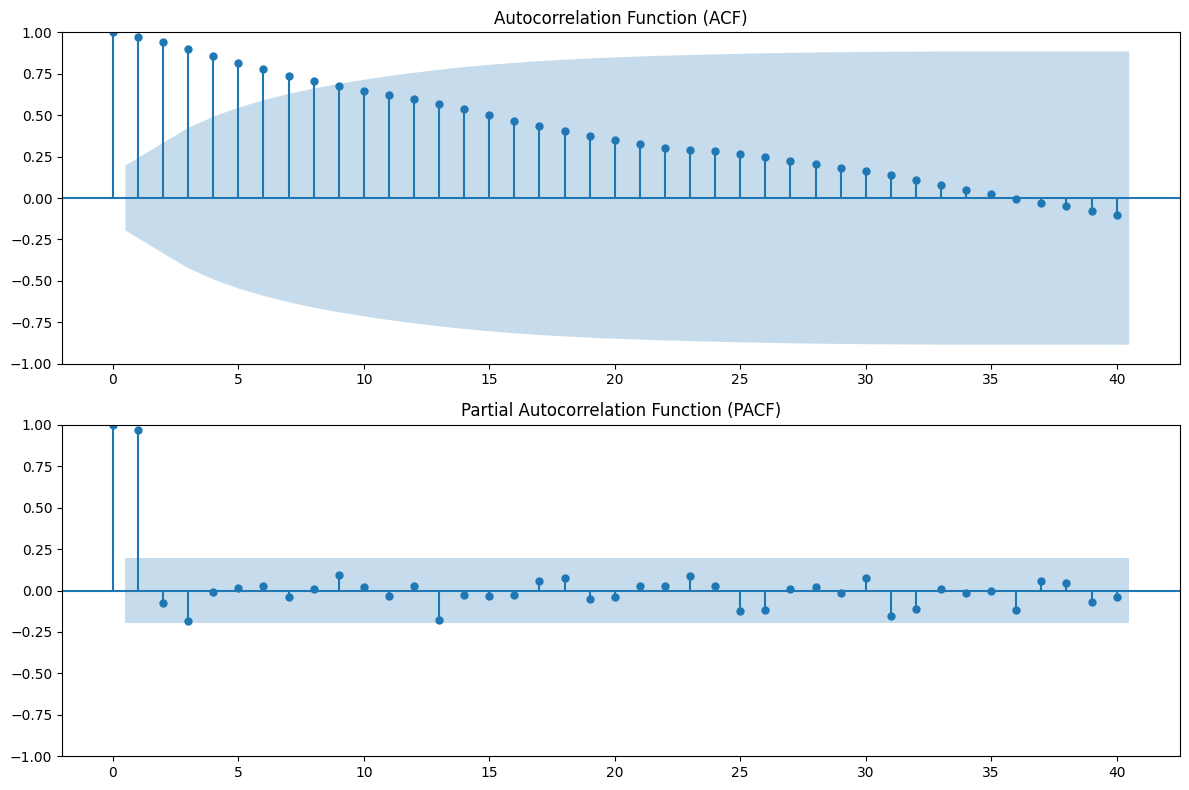


Augmented Dickey-Fuller Test:
Test Statistic                 -0.793000
p-value                         0.821170
#Lags Used                      1.000000
Number of Observations Used    98.000000
Critical Value (1%)            -3.498910
Critical Value (5%)            -2.891516
Critical Value (10%)           -2.582760
dtype: float64

Result: The time series is likely non-stationary (p-value > 0.05).


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Assuming 'df' with 'Adj Close' is already loaded and available

# --- Autocorrelation and Partial Autocorrelation Plots ---
ts = df["Adj Close"].dropna()

plt.figure(figsize=(12, 8))
plt.subplot(211)
plot_acf(ts, ax=plt.gca(), lags=40)  # Adjust lags as needed
plt.title("Autocorrelation Function (ACF)")

plt.subplot(212)
plot_pacf(ts, ax=plt.gca(), lags=40)  # Adjust lags as needed
plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

# --- Augmented Dickey-Fuller (ADF) Test for Stationarity ---
print("\nAugmented Dickey-Fuller Test:")
adf_test = adfuller(ts)
adf_output = pd.Series(adf_test[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adf_test[4].items():
    adf_output['Critical Value (%s)' % key] = value
print(adf_output)

# Interpret the ADF test result
if adf_test[1] <= 0.05:
    print("\nResult: The time series is likely stationary (p-value <= 0.05).")
else:
    print("\nResult: The time series is likely non-stationary (p-value > 0.05).")